# Heavy Equipment Selling Price Prediction

## Problem Statement
The global heavy equipment market involves thousands of transactions daily, spanning bulldozers, excavators, forklifts, cranes, and other industrial machinery. Accurately pricing these assets is critical for auctioneers, fleet managers, and financial institutions — yet valuations are complex, influenced by age, usage, configuration, geography, and market timing simultaneously.

This competition presents a real-world dataset of finalized equipment transactions, each capturing rich operational, technical, and geographic metadata. The goal is to build a predictive model that can estimate the selling price of a piece of heavy equipment given its characteristics at the time of sale.

## Type of ML Problem
This is a **supervised regression** problem.
- **Input:** Transactional and technical features describing a piece of equipment
- **Target:** `TargetValue` — the realized selling price in USD
- **Evaluation Metric:** Root Mean Squared Logarithmic Error (RMSLE)

RMSLE is chosen because selling prices span a wide range ($7,500 to $142,000), and the metric penalizes relative errors rather than absolute ones — meaning an error of $5,000 on a $10,000 machine is penalized more heavily than the same error on a $100,000 machine. This makes log-transforming the target before training the natural modeling choice.

## Dataset Summary
| Property | Detail |
|---|---|
| Train size | 138,701 transactions |
| Test size | 15,000 transactions |
| Features | 49 (operational, technical, geographic, temporal) |
| Target | TargetValue (USD) |
| Target range | $7,500 — $142,000 |
| Missing data | Significant — up to 99% in some spec columns |

## Approach Overview
1. **EDA** — Understand target distribution, missingness patterns, and feature relationships
2. **Feature Engineering** — Extract signals from dates, specs, usage metrics, and configurations
3. **Preprocessing** — Target encoding for high-cardinality features, OHE for low-cardinality
4. **Modeling** — LightGBM, XGBoost, and HistGradientBoosting with ensemble blending
5. **Evaluation** — RMSLE on a held-out validation set, final submission on test set

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

sns.set_style("whitegrid")

TARGET = "TargetValue"

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


## 1. Load Datasets

In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')

train_df_original = train_df.copy()
test_df_original = test_df.copy()

/tmp/ipykernel_16/111137073.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


In [3]:
print(train_df.shape)
print(test_df.shape)
train_df.head()

(138701, 50)
(15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


## 2. Understanding Data

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [5]:
train_df.isna().sum()

TransactionID                     0
TargetValue                       0
AssetID                           0
ProductConfigID                   0
DataOriginCode                    0
VendorPartnerID                   0
ManufactureYear                   0
OperationalHoursMeter         56643
UtilizationTier               88226
TransactionDate                   0
Spec_FullDescriptor               0
Spec_BaseClass                    0
Spec_SubClass                 36985
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              41210
FunctionalClassification          0
RegionCode                        0
InventoryGroupCategory            0
InventoryGroupDescription         0
col1                         104915
CabinType                         0
Forks                        109382
col3                         109448
col4                         128320
DrivetrainType                89956
col5                         128320
col6                        

In [6]:
train_df.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


In [7]:
for col in train_df.columns:
    print(col, train_df[col].nunique())

TransactionID 138701
TargetValue 675
AssetID 120111
ProductConfigID 3594
DataOriginCode 6
VendorPartnerID 31
ManufactureYear 68
OperationalHoursMeter 14643
UtilizationTier 3
TransactionDate 3676
Spec_FullDescriptor 3505
Spec_BaseClass 1249
Spec_SubClass 147
Spec_ReleaseSeries 113
Spec_VariantModifier 132
AssetScaleFactor 6
FunctionalClassification 65
RegionCode 53
InventoryGroupCategory 6
InventoryGroupDescription 6
col1 4
CabinType 3
Forks 2
col3 3
col4 2
DrivetrainType 8
col5 2
col6 2
col7 6
col8 3
col9 2
col10 11
col11 2
col12 4
col13 2
col14 3
col15 15
col16 3
col18 2
col19 2
col20 2
col21 18
col22 27
col23 3
col24 3
col25 3
col27 9
col28 5
col29 3
col30 2


### 2.1 Dataset Overview

In [8]:
print("Target Value Summary")
print(train_df['TargetValue'].describe().round(2))

print("\nDataset Overview")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Unique machine classes: {train_df['Spec_BaseClass'].nunique()}")
print(f"Unique vendors: {train_df['VendorPartnerID'].nunique()}")
print(f"Date range: {train_df['TransactionDate'].min()} to {train_df['TransactionDate'].max()}")
print(f"% records with missing hours: {train_df['OperationalHoursMeter'].isnull().mean()*100:.1f}%")

Target Value Summary
count    138701.00
mean      41521.87
std       26361.13
min        7500.00
25%       20500.00
50%       35000.00
75%       57000.00
max      142000.00
Name: TargetValue, dtype: float64

Dataset Overview
Train shape: (138701, 50)
Test shape: (15000, 49)
Unique machine classes: 1249
Unique vendors: 31
Date range: 1990-01-31 to 2013-04-28
% records with missing hours: 40.8%


Observations:

* The dataset spans transactions across 53 regions with 31 vendors and 1,249 unique machine classes.
* 40.8% of records are missing operational hours, making it one of the most impactful missing features to handle carefully.
* The train set (138,701 rows) is roughly 9× the size of the test set (15,000 rows), giving sufficient data for robust model training.

### 2.2 Target Value Distribution

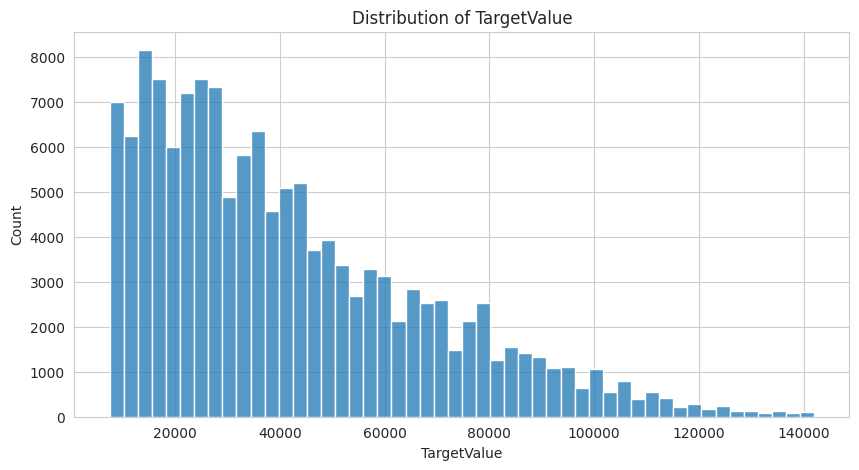

Skewness: 0.9699859082371339


In [9]:
# Raw target distribution

plt.figure(figsize=(10,5))

sns.histplot(train_df[TARGET], bins=50)

plt.title("Distribution of TargetValue")
plt.xlabel("TargetValue")
plt.ylabel("Count")

plt.show()

print("Skewness:", skew(train_df[TARGET].dropna()))

Observations:

* Distribution is heavily right-skewed.
* Majority of machines are concentrated in lower price ranges.
* Small number of extremely expensive machines create a long tail.
* Log transformation is therefore justified.

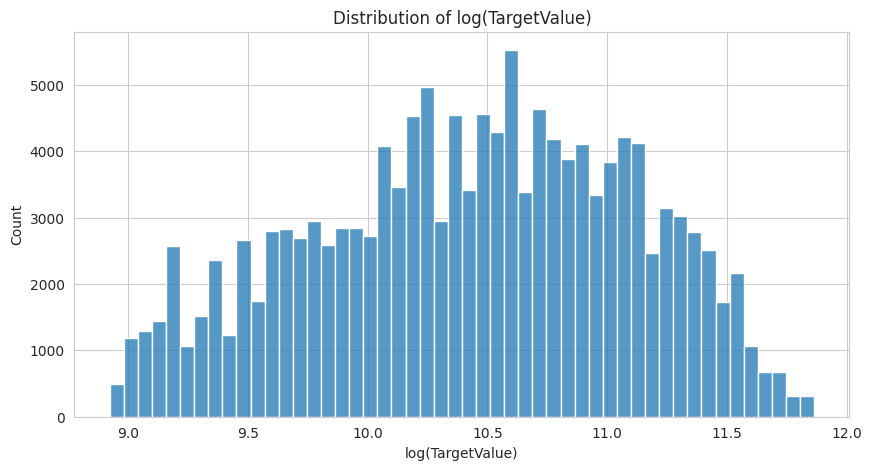

Skewness: -0.19830175927071336


In [10]:
# Log-transformed target Distribution

plt.figure(figsize=(10,5))

sns.histplot(np.log1p(train_df[TARGET]), bins=50)

plt.title("Distribution of log(TargetValue)")
plt.xlabel("log(TargetValue)")
plt.ylabel("Count")

plt.show()

print("Skewness:", skew(np.log1p(train_df[TARGET].dropna())))

Observations:

* Log transformation substantially reduces skewness.
* Distribution becomes closer to normal.
* RMSLE optimization becomes more appropriate.

### 2.3 Missing Value Analysis

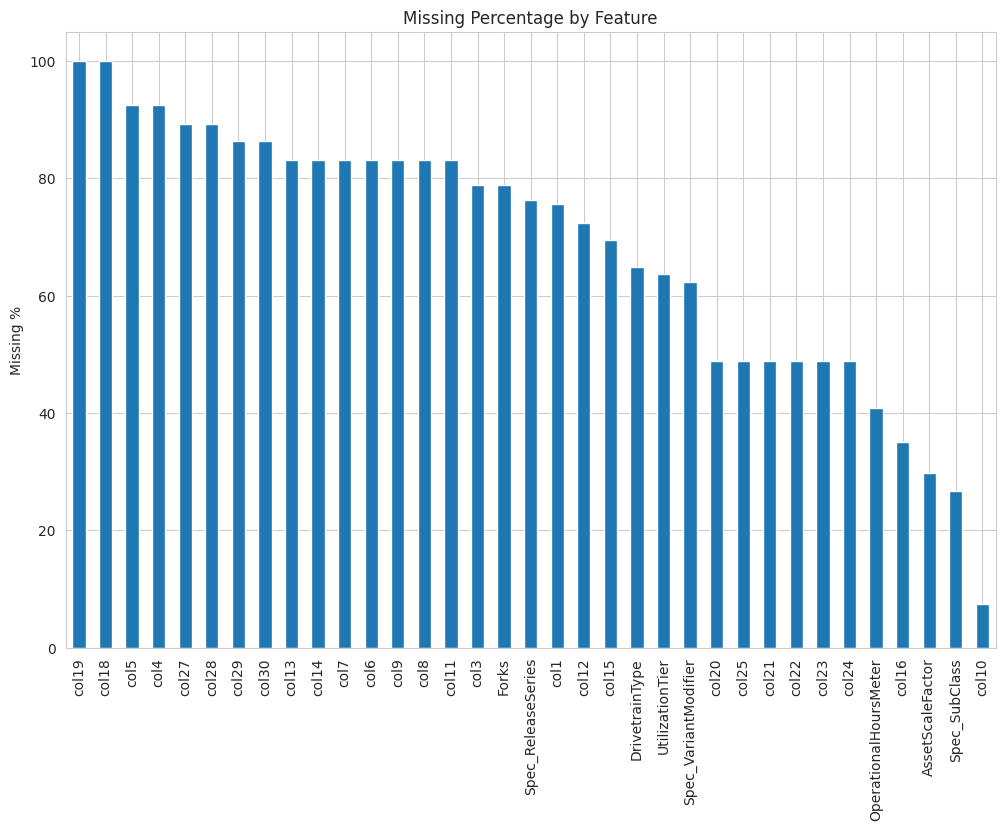

In [11]:
# Missing percentage by column

missing_pct = (train_df.isnull().mean().sort_values(ascending=False)* 100)

plt.figure(figsize=(12,8))

missing_pct[missing_pct > 0].plot(kind="bar")

plt.title("Missing Percentage by Feature")
plt.ylabel("Missing %")

plt.show()

Observations

* Due to their extremely high missingness, col18 and col19 were unlikely to contribute reliably to the model and were therefore removed to reduce sparsity and preprocessing complexity.
* OperationalHoursMeter, despite having 40.8% missing values, was retained because it directly measures machine usage and is expected to be highly predictive. This motivated careful imputation and the creation of derived features rather than dropping the column.
* UtilizationTier (63.6% missing) and Spec_ReleaseSeries (76.3% missing) are partially available and retained since their presence alone is informative.
* Overall, the missing-value analysis guided three different preprocessing strategies: dropping extremely sparse features, retaining informative but partially observed features, and engineering missing-value indicators where appropriate.

### 2.5 Numerical Correlations

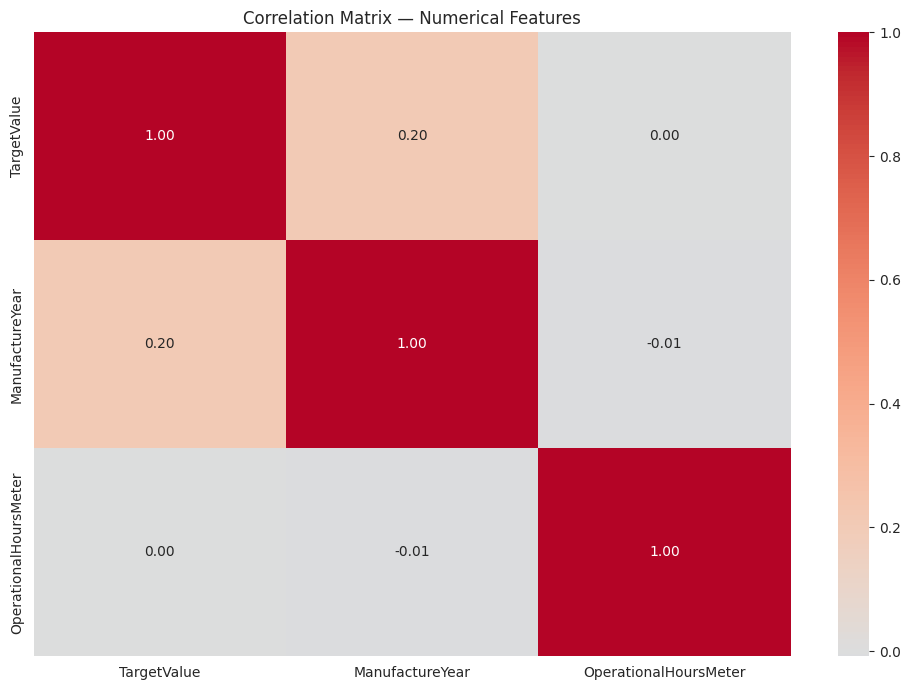

In [12]:
num_cols = ['TargetValue', 'ManufactureYear', 'OperationalHoursMeter']

num_cols = [c for c in num_cols if c in train_df.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(
    train_df[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

Observations

* ManufactureYear exhibits a weak positive correlation (0.20) with TargetValue, indicating that newer machines generally have higher resale values.
* OperationalHoursMeter shows almost no linear correlation (≈0.00) with TargetValue. This suggests that raw operating hours alone are insufficient to explain machine price and motivates deriving more informative usage-related features later.
* The weak pairwise correlations indicate that simple linear relationships do not fully capture the factors affecting equipment prices. This motivates feature engineering and the use of nonlinear models such as LightGBM.

### 2.6 Machine Category Exploration

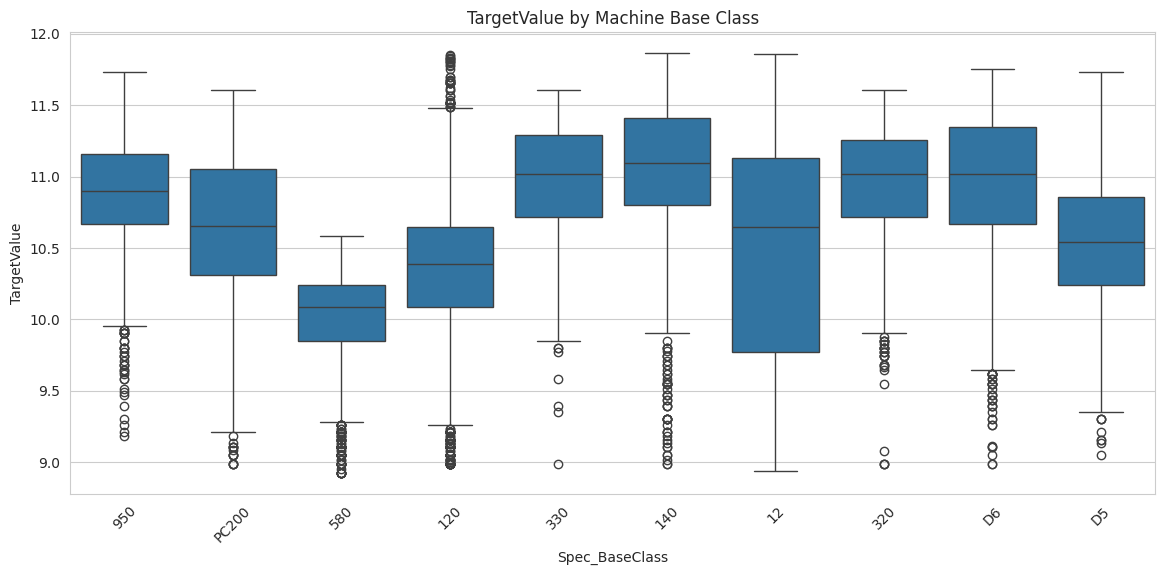

In [13]:
# Influence of machine type on price

top_class_names = (train_df["Spec_BaseClass"].value_counts().head(10).index)

subset = train_df[train_df["Spec_BaseClass"].isin(top_class_names)]

plt.figure(figsize=(14,6))

sns.boxplot(data=subset, x="Spec_BaseClass", y=np.log1p(subset[TARGET]))

plt.xticks(rotation=45)

plt.title("TargetValue by Machine Base Class")

plt.show()

Observations

* The median target value differs across machine base classes, indicating that Spec_BaseClass is likely to be an informative predictive feature.
* Considerable variation exists within each machine class, suggesting that machine category alone cannot fully explain the target value.
* The spread of the target distribution varies across categories, indicating that additional factors influence different machine classes to different extents.
* Outliers are consistently observed across most machine classes, suggesting genuine variability in the dataset rather than isolated data quality issues.

## 3. Handling Missing Values

In [14]:
missing_pct = train_df.isnull().mean()

cols_to_drop = missing_pct[missing_pct > 0.90].index.tolist()

print("Dropping:", cols_to_drop)

train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

Dropping: ['col4', 'col5', 'col18', 'col19']


* Columns with more than 90% missing values were removed because their extreme sparsity provides too little information for reliable learning.
* The remaining missing values were retained since the primary models (LightGBM and XGBoost) can handle missing values natively.
* Additionally, missing-value indicator features were created later to preserve potentially informative missingness patterns.

## 4. Feature Engineering

All features in this section are derived from individual rows only (date parsing, 
arithmetic, string operations). No cross-row statistics are computed here, 
so these transformations are safe to apply before the train/validation split.

In [15]:
# Engineering Date Columns
train_df['TransactionDate'] = pd.to_datetime(train_df['TransactionDate'])
test_df['TransactionDate'] = pd.to_datetime(test_df['TransactionDate'])

for df in [train_df, test_df]:
    df['TransactionYear'] = df['TransactionDate'].dt.year
    df['TransactionMonth'] = df['TransactionDate'].dt.month
    df['TransactionDay'] = df['TransactionDate'].dt.day
    df['AssetAge'] = df['TransactionYear'] - df['ManufactureYear']

train_df.drop(columns=['TransactionDate', 'ManufactureYear'], inplace=True)
test_df.drop(columns=['TransactionDate', 'ManufactureYear'], inplace=True)

# Row-level features
for df in [train_df, test_df]:
    df['HoursPerYear'] = df['OperationalHoursMeter'] / (df['AssetAge'] + 1)
    df['MachineUsed'] = (df['OperationalHoursMeter'] > 0).astype(int)
    df['AgeGroup'] = pd.cut(
        df['AssetAge'], bins=[-1,3,8,20,100],
        labels=['New','MidLife','Old','VeryOld']
    )
    df['TransactionQuarter'] = ((df['TransactionMonth'] - 1) // 3 + 1)
    df['MonthSin'] = np.sin(2 * np.pi * df['TransactionMonth'] / 12)
    df['MonthCos'] = np.cos(2 * np.pi * df['TransactionMonth'] / 12)
    
# Spec_FullDescriptor Parsing — row-level string ops, safe before split
def extract_numeric(text):
    nums = re.findall(r'\d+', str(text))
    return int(nums[0]) if nums else np.nan

def descriptor_length(text):
    return len(str(text))

for df in [train_df, test_df]:
    df['Spec_Number'] = df['Spec_FullDescriptor'].apply(extract_numeric)
    df['Spec_Length'] = df['Spec_FullDescriptor'].apply(descriptor_length)

# Interaction Features — row-level, safe before split
for df in [train_df, test_df]:
    df['Base_Sub'] = df['Spec_BaseClass'].astype(str) + "_" + df['Spec_SubClass'].astype(str)
    df['Cabin_Drive'] = df['CabinType'].astype(str) + "_" + df['DrivetrainType'].astype(str)
    df['Inventory_Function'] = df['InventoryGroupCategory'].astype(str) + "_" + df['FunctionalClassification'].astype(str)

# Missingness Features — row-level, safe before split
spec_cols = [c for c in train_df.columns if c.startswith("col")]

for df in [train_df, test_df]:
    df['null_count'] = df[spec_cols].isnull().sum(axis=1)
    for col in spec_cols:
        df[col+"_missing"] = df[col].isnull().astype(int)

# Tier-hours conflict — row-level, safe before split
tier_map = {'Low': 0, 'Medium': 1, 'High': 2}
for df in [train_df, test_df]:
    df['UtilizationTier_num'] = df['UtilizationTier'].map(tier_map)

* AssetAge and HoursPerYear transform raw temporal and usage information into more meaningful measures of machine age and usage intensity, which are likely to be more predictive than the original features alone.
* Date-derived features (TransactionYear, TransactionMonth, TransactionDay, TransactionQuarter, MonthSin, and MonthCos) capture temporal and seasonal patterns while preserving the cyclic nature of months.
* Features extracted from Spec_FullDescriptor (Spec_Number and Spec_Length) convert unstructured textual information into structured numerical features that the model can readily utilize.
* Interaction features such as Base_Sub, Cabin_Drive, and Inventory_Function capture meaningful combinations of categorical attributes, enabling the model to learn relationships that individual features may not fully represent.
* Missing-value indicators (*_missing) and null_count preserve potentially informative missingness patterns observed during EDA, allowing the model to distinguish between unavailable and absent machine specifications.

## 5. Preprocessing

The train/validation split is performed **first**, before any statistic is computed across rows. This ensures no information from validation or test rows influences the encodings learned from training data.

In [16]:
# Create X, y and SPLIT

drop_cols = [
    'TransactionID', 'TargetValue',
    'Spec_FullDescriptor', 'AssetID', 'ProductConfigID'
]

X_raw = train_df.drop(columns=drop_cols)
X_test_raw = test_df.drop(columns=['TransactionID'])
y = np.log1p(train_df['TargetValue'])

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train_raw.shape}, Val: {X_val_raw.shape}")

Train: (110960, 79), Val: (27741, 79)


### 5.1 Aggregation Features

Class-level means and rarity scores are computed exclusively from the 
training split and applied to validation and test sets.

- `hours_vs_class_mean` — normalizes operational hours relative to the 
  average for each machine class, isolating over/underuse
- `rarity_score` — counts how many of a machine's categorical values 
  appear in fewer than 1% of training records, flagging unusual configurations

In [17]:
# AGGREGATION FEATURES - fit on train only

# hours_vs_class_mean
class_mean_hours = X_train_raw.groupby('Spec_BaseClass')['OperationalHoursMeter'].mean()

for df in [X_train_raw, X_val_raw, X_test_raw]:
    df['hours_vs_class_mean'] = (
        df['OperationalHoursMeter'] / df['Spec_BaseClass'].map(class_mean_hours)
    ).fillna(1.0)

# Rarity Score
cat_cols_rarity = [
    'col1','col3','col6','col7','col8',
    'col9','col10','col11','col12','col13','col14',
    'col15','col16','col20','col21','col22'
]

rarity_maps = {
    c: X_train_raw[c].value_counts(normalize=True)
    for c in cat_cols_rarity if c in X_train_raw.columns
}

for df in [X_train_raw, X_val_raw, X_test_raw]:
    df['rarity_score'] = sum(
        (df[c].map(rarity_maps[c]) < 0.01).astype(int)
        for c in cat_cols_rarity if c in df.columns
    )

print("Aggregation features added.")

Aggregation features added.


### 5.2 Frequency Encoding

Frequency of each category value is computed from training data only 
and mapped onto all splits. This gives the model a sense of how common 
or rare each vendor, region, or spec class is — without introducing leakage.

In [18]:
# FREQUENCY ENCODING - fit on train only

freq_cols = [
    'VendorPartnerID', 'RegionCode',
    'Spec_BaseClass', 'Spec_SubClass',
    'Spec_ReleaseSeries', 'Spec_VariantModifier'
]

for col in freq_cols:
    freq = X_train_raw[col].value_counts()
    X_train_raw[col+"_freq"] = X_train_raw[col].map(freq)
    X_val_raw[col+"_freq"] = X_val_raw[col].map(freq)
    X_test_raw[col+"_freq"] = X_test_raw[col].map(freq)

print("Frequency encoding done.")

Frequency encoding done.


### 5.3 Target Encoding

High-cardinality categorical columns are encoded using their mean 
log(TargetValue), computed via 5-fold cross-validation on the training 
set. This prevents a row from being encoded using its own target value.

The full training mean is used to encode the test set.
These encoded columns replace the original high-cardinality columns 
entirely, capturing their price signal in a single dense feature each.

In [19]:
# TARGET ENCODING with CV - fit on train only

def target_encode_cv(train_df, test_df, column, target, n_splits=5):
    train_encoded = pd.Series(index=train_df.index, dtype=float)
    global_mean = train_df[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(train_df):
        fold_train = train_df.iloc[train_idx]
        fold_val = train_df.iloc[val_idx]
        means = fold_train.groupby(column)[target].mean()
        train_encoded.iloc[val_idx] = fold_val[column].map(means)

    train_encoded.fillna(global_mean, inplace=True)
    means = train_df.groupby(column)[target].mean()
    test_encoded = test_df[column].map(means).fillna(global_mean)
    return train_encoded, test_encoded

target_encode_cols = [
    'VendorPartnerID', 'RegionCode', 'ProductConfigID',
    'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries',
    'Spec_VariantModifier', 'FunctionalClassification',
    'DataOriginCode', 'AssetID'
]

train_df['LogTarget'] = np.log1p(train_df['TargetValue'])

for col in target_encode_cols:
    train_df[col+'_TE'], test_df[col+'_TE'] = target_encode_cv(
        train_df, test_df, column=col, target='LogTarget'
    )

# Add TE cols to raw splits using index alignment
te_cols = [col+'_TE' for col in target_encode_cols]

for col in te_cols:
    X_train_raw[col] = train_df.loc[X_train_raw.index, col].values
    X_val_raw[col] = train_df.loc[X_val_raw.index,   col].values
    X_test_raw[col] = test_df[col].values

print("Target encoding done. TE cols added to raw splits.")

Target encoding done. TE cols added to raw splits.


### 5.4 Drop Original High-Cardinality Columns

The original categorical columns that were target-encoded are now dropped 
before One-Hot Encoding. This prevents them from exploding into thousands 
of sparse dummy columns and keeps the final feature matrix compact.

In [20]:
# These are now replaced by their _TE versions — DROP ORIGINALS before OHE 
# so that they do not explode into thousands of sparse features.

high_card_drop = [
    'VendorPartnerID', 'RegionCode', 'ProductConfigID',
    'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries',
    'Spec_VariantModifier', 'FunctionalClassification',
    'DataOriginCode', 'AssetID'
]

for df in [X_train_raw, X_val_raw, X_test_raw]:
    df.drop(columns=[c for c in high_card_drop if c in df.columns], inplace=True)

print("High-cardinality columns dropped.")
print(f"X_train_raw shape after drop: {X_train_raw.shape}")

High-cardinality columns dropped.
X_train_raw shape after drop: (110960, 89)


### 5.5 One-Hot Encoding

OHE is applied only to the remaining low-cardinality categorical columns. 
The encoding structure is derived from the training set — validation and 
test sets are reindexed to match exactly, with unseen categories filled 
with zero rather than creating new columns.

In [21]:
# OHE on remaining low cardinality categorical columns only

# Convert category dtype first
for df in [X_train_raw, X_val_raw, X_test_raw]:
    for col in df.columns:
        if str(df[col].dtype) == 'category':
            df[col] = df[col].astype(str)

# OHE — now only applied to low-cardinality cols
X_train_enc = pd.get_dummies(X_train_raw, dummy_na=True)
X_val_enc = pd.get_dummies(X_val_raw, dummy_na=True)
X_test_enc = pd.get_dummies(X_test_raw, dummy_na=True)

# Deduplicate before reindexing
X_train_enc = X_train_enc.loc[:, ~X_train_enc.columns.duplicated()]
X_val_enc = X_val_enc.loc[:, ~X_val_enc.columns.duplicated()]
X_test_enc = X_test_enc.loc[:, ~X_test_enc.columns.duplicated()]

# Reindex val and test to train structure
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns,  fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Clean column names
def clean_cols(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', str(c)) for c in df.columns]
    return df.loc[:, ~df.columns.duplicated()]

X_train_enc = clean_cols(X_train_enc)
X_val_enc = clean_cols(X_val_enc)
X_test_enc = clean_cols(X_test_enc)

print(f"After OHE — X_train: {X_train_enc.shape}")

After OHE — X_train: (110960, 2513)


### 5.6 Final Feature Matrix

Missing values are filled with -999, a sentinel value that tree-based 
models can distinguish from valid entries. The full feature matrix X 
is reconstructed by concatenating train and validation for use in the 
final model trained on 100% of the data.

In [22]:
# FILL NULLS and finalize feature matrix

X_train = X_train_enc.fillna(-999)
X_val = X_val_enc.fillna(-999)
X_test = X_test_enc.fillna(-999)

# Full X for final model
X = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = np.log1p(train_df['TargetValue'])

print("Final Feature Matrix")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"X (full): {X.shape}")
print(f"\nTE features: {[c for c in X_train.columns if c.endswith('_TE')]}")
print(f"Missing in X_train: {X_train.isnull().sum().sum()}")

Final Feature Matrix
X_train: (110960, 2513)
X_val: (27741, 2513)
X_test: (15000, 2513)
X (full): (138701, 2513)

TE features: ['VendorPartnerID_TE', 'RegionCode_TE', 'ProductConfigID_TE', 'Spec_BaseClass_TE', 'Spec_SubClass_TE', 'Spec_ReleaseSeries_TE', 'Spec_VariantModifier_TE', 'FunctionalClassification_TE', 'DataOriginCode_TE', 'AssetID_TE']
Missing in X_train: 0


**Observations:**
- Dropping high-cardinality columns before OHE reduced the feature matrix 
  from ~4,259 to significantly fewer columns, reducing noise from sparse dummies
- All 10 target-encoded features are confirmed present
- Zero missing values in the final training matrix
- Val and test sets have identical column structure to train, ensuring 
  no shape mismatches during prediction

## 7. Model Training

In [23]:
# Baseline Model 1

from sklearn.ensemble import HistGradientBoostingRegressor

y = np.log1p(train_df['TargetValue'])

hist = HistGradientBoostingRegressor(
    random_state=42
)

hist.fit(X_train, y_train)

hist_pred = np.expm1(hist.predict(X_val))
hist_pred = np.maximum(hist_pred, 0)
hist_rmsle = root_mean_squared_log_error(np.expm1(y_val), hist_pred)

print(hist_rmsle)

0.22632629731786494


In [24]:
# Baseline LGBM

lgb_base = LGBMRegressor(
    random_state=42,
    verbose=-1
)

lgb_base.fit(X_train, y_train)

lgb_pred = np.expm1(lgb_base.predict(X_val))
lgb_pred = np.maximum(lgb_pred, 0)

lgb_base_rmsle = root_mean_squared_log_error(
    np.expm1(y_val),
    lgb_pred
)

print("Baseline LightGBM RMSLE:", lgb_base_rmsle)

Baseline LightGBM RMSLE: 0.22634494544324327


In [25]:
# Baseline XGBoost

xgb_base = XGBRegressor(
    random_state=42,
    tree_method="hist"
)

xgb_base.fit(X_train, y_train)

xgb_pred = np.expm1(xgb_base.predict(X_val))
xgb_pred = np.maximum(xgb_pred, 0)

xgb_base_rmsle = root_mean_squared_log_error(
    np.expm1(y_val),
    xgb_pred
)

print("Baseline XGBoost RMSLE:", xgb_base_rmsle)

Baseline XGBoost RMSLE: 0.22156160158955435


In [26]:
# Baseline Comparison

baseline_results = pd.DataFrame({

    "Model":[
        "HistGradient",
        "LightGBM (Default)",
        "XGBoost (Default)"
    ],

    "RMSLE":[
        hist_rmsle,
        lgb_base_rmsle,
        xgb_base_rmsle
    ]
})

baseline_results.sort_values("RMSLE")

,Model,RMSLE
2,XGBoost (Default),0.221562
0,HistGradient,0.226326
1,LightGBM (Default),0.226345


## 8. Hyperparameter Tuning

### LGBM Tuning

In [27]:
param_dist = {

    "learning_rate": [0.005, 0.01],

    "num_leaves": [127, 255],

    "min_child_samples": [10, 15],

    "subsample": [0.7, 0.9],

    "colsample_bytree": [0.5, 0.7],

    "reg_alpha": [0, 0.05],

    "reg_lambda": [0.5, 1.0]
}

search = RandomizedSearchCV(

    estimator=LGBMRegressor(
        n_estimators=1000,
        subsample_freq=1,
        random_state=42,
        verbose=-1
    ),

    param_distributions=param_dist,

    n_iter=20,

    scoring="neg_root_mean_squared_error",

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=0
)

search.fit(X_train, y_train)

best_params = search.best_params_

print("Best Parameters:")
print(best_params)

print("\nBest CV RMSE:")
print(-search.best_score_)

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'num_leaves': 255, 'min_child_samples': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Best CV RMSE:
0.20915536146593414


In [28]:
lgbm = LGBMRegressor(

    n_estimators=5000,

    subsample_freq=1,

    random_state=42,

    verbose=-1,

    **best_params
)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(100, verbose=False),
        lgb.log_evaluation(200)
    ]
)

lgbm_pred = np.expm1(lgbm.predict(X_val))
lgbm_pred = np.maximum(lgbm_pred, 0)

lgbm_rmsle = root_mean_squared_log_error(
    np.expm1(y_val),
    lgbm_pred
)

print("Tuned LightGBM RMSLE:", lgbm_rmsle)

[200]	valid_0's l2: 0.062614
[400]	valid_0's l2: 0.0479061
[600]	valid_0's l2: 0.044723
[800]	valid_0's l2: 0.0431704
[1000]	valid_0's l2: 0.042217
[1200]	valid_0's l2: 0.0416157
[1400]	valid_0's l2: 0.0411738
[1600]	valid_0's l2: 0.04085
[1800]	valid_0's l2: 0.040578
[2000]	valid_0's l2: 0.0403585
[2200]	valid_0's l2: 0.0401691
[2400]	valid_0's l2: 0.0400087
[2600]	valid_0's l2: 0.0398844
[2800]	valid_0's l2: 0.0397633
[3000]	valid_0's l2: 0.0396383
[3200]	valid_0's l2: 0.0395308
[3400]	valid_0's l2: 0.0394403
[3600]	valid_0's l2: 0.0393468
[3800]	valid_0's l2: 0.0392751
[4000]	valid_0's l2: 0.0392081
[4200]	valid_0's l2: 0.0391426
[4400]	valid_0's l2: 0.0390849
[4600]	valid_0's l2: 0.0390307
[4800]	valid_0's l2: 0.0389872
[5000]	valid_0's l2: 0.0389467
Tuned LightGBM RMSLE: 0.1973493068001038


## 10. Final Submission

In [29]:
# Train lgbm on full training data

lgbm_full = LGBMRegressor(
    n_estimators=lgbm.best_iteration_,  # use the iteration found by early stopping
    random_state=42,
    verbose=-1,
    **best_params
)

lgbm_full.fit(X, np.log1p(train_df['TargetValue']))

LGBMRegressor(colsample_bytree=0.7, learning_rate=0.01, min_child_samples=15,
              n_estimators=5000, num_leaves=255, random_state=42,
              reg_alpha=0.05, reg_lambda=0.5, subsample=0.9, verbose=-1)

In [30]:
# Feature Importances

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_full.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False)

importance.head(20)

importance[importance['Feature'].str.contains('_TE')].sort_values(
    'Importance', ascending=False).head(20)

,Feature,Importance
46,RegionCode_TE,90854
47,ProductConfigID_TE,63062
45,VendorPartnerID_TE,58022
48,Spec_BaseClass_TE,55755
52,FunctionalClassification_TE,53874
53,DataOriginCode_TE,46966
49,Spec_SubClass_TE,40353
54,AssetID_TE,27852
51,Spec_VariantModifier_TE,21081
50,Spec_ReleaseSeries_TE,14352


In [31]:
# Align X_test to exactly match training columns
X_test = X_test.reindex(columns=X.columns, fill_value=0)

final_pred = np.expm1(lgbm_full.predict(X_test))
final_pred = np.maximum(final_pred, 0)

submission = pd.DataFrame({
    'TransactionID': test_df['TransactionID'],
    'TargetValue': final_pred
})

submission.to_csv('submission.csv', index=False)
print("Submission generated using LGBM")

Submission generated using LGBM


* The final submission uses the full-data LightGBM model (trained on 100% 
of train) for predictions.
* X_test is reindexed to exactly match the training feature columns before prediction to prevent shape mismatches. 
* Predictions are clipped at 0 to remove any negative values introduced 
by the inverse log transformation.